## Module 4: Cancer Hallmark

## Team Members:
*Abhiram Ruthala, Delaney Broderick*

## Project Title:
*The Impact of Immune Response Invasion Genes in individuals with Glioblastoma Across Different Ages*


## Project Goal:
This project seeks to understand how the different genes associated with the immune response invasion cancer hallmark is expressed in individuals with glioblastoma in different age ranges. Using the cancer hallmark of immune invasion response and the associated genes, to see if there is a difference in gene expression in individuals with glioblastoma by age. This can be used to help predict gene expression in certain age groups of those with glioblastoma. 

## Disease Background:

* Cancer Hallmark focus: Immune response evasion
* Overview of hallmark: 
    * Immune Response Evasion: Cancer cells are able to evade immune cells, such as Killer T cells, as they traverse through the human body and continue to develop uncontrollably. Due to this evasion, it makes it harder for the immune system to attack the cancer cells, causing the cancer to prevail for longer with minimal damage. This is a programming of the cancer cell as per its sense of dividing as much as possible.
* Genes associated with hallmark: Immune evasion hallmark includes key oncogenes such as MYC, RAS, and STAT3, and tumor suppressors TP53 and PTEN, which are important for immune suppresion and to avoid detection by key immune cells. 

### Background on Glioblastoma
Glioblastoma is an aggressive type of brain cancer that begins with astrocytes (support nerve cells). Specifically, glial cells - cells in the central and peripheral nervous system - that endure a major mutation/change in the DNA, which then causes them to fail within their own division processes, leading to glioblastoma. Glioblastoma is the most common malignant form of glioma, representing a wide array of glial cell-formed brain cancer.

It's the most common malignant brain tumor in adults and makes up about half of all malignant brain tumors in adults.

Within this group, glioblastoma is classified as a grade 4 glioma (Mayo Clinic, 2024a), the most serious type of glioma. Grade 4 means the tumor grows and spreads quickly into nearby brain tissue, which makes it hard to remove completely.

Symptoms:
Symptoms vary based on where the tumor forms in the brain and may involve seizures, brain swelling, headaches, personality changes, and changes in speech, vision, strength, sensation or balance.

There is no cure for glioblastoma. Treatments such as surgery, radiation and chemotherapy may slow tumor growth, ease symptoms and help people live longer. These are treatment methods that hope to put the cancer in remission by removing the mass, killing off cells that divide fast, and creating environments to where it is harder for such fast-dividing cells to live.

The cause of most glioblastomas is not known. A lot can be pointed to major mutations or transcription factor changes within glial cells that cause them to mishap when dividing as a means to support the brain's nutrition. Poor lifestyle choices compounded over years creates more effective breeding grounds for cancer as mistakes for cells are more prone, the body's immune response drops with time, and cells have accumulated damage from years of previous mistakes as well. 

Risk Factors: 
* Radiation exposure 
* Old age
* Being male
* Inherited syndromes like Lynch Syndrome and Li-Fraumeni syndrome

There are no known mechanisms as to prevent glioblastoma. A lot of general mechanisms point to public health awareness and lifestyle changes as being a deep factor, since that reduces the abilities for cells to drift, make changes, and have unnecessary mutations that would've taken place if not for proper cell management. However, people can still develop severe versions even when organized healthily, because biology's laws aren't limited.

### Citations

Mayo Clinic. (2024a). Astrocytoma - Symptoms and causes. Mayo Clinic. https://www.mayoclinic.org/diseases-conditions/astrocytoma/symptoms-causes/syc-20576675

Mayo Clinic. (2024b, June 20). Glioblastoma - Symptoms and causes. Mayo Clinic. https://www.mayoclinic.org/diseases-conditions/glioblastoma/symptoms-causes/syc-20569077


## Data-Set: 

We will be analyzing the metadata dataset first as a means to filter through and identify key factor points for Glioblastoma. After recognizing such pointers, we'll take a look into the training data, and filter within that for glioblastoma patients. Since we'd get a range of glioblastoma patients, we'd want to sort this data through age, and then format to find immune evasion factors, ideally through specific metabolic changes or gene expression changes.

The Cancer Genome Atlas RNA-seq dataset, re-processed by Rahman et al. The data set contains 24 cancer types. It contains 50-100 tumors per cancer type and the metadata includes ~20 columns from original 526. The rows of the metadata document that contains individuals with glioblastoma (GBM) were used in our analysis. 


### Citations

smgroves. (2025a). Module-4-Cancer/data/GSE62944_metadata_percent_nonNA_by_cancer_type.csv at main · smgroves/Module-4-Cancer. GitHub. https://github.com/smgroves/Module-4-Cancer/blob/main/data/GSE62944_metadata_percent_nonNA_by_cancer_type.csv

smgroves. (2025b). Module-4-Cancer/data/TRAINING_SET_GSE62944_metadata.csv at main · smgroves/Module-4-Cancer. GitHub. https://github.com/smgroves/Module-4-Cancer/blob/main/data/TRAINING_SET_GSE62944_metadata.csv






## Data Analysis: 

### Methods
The machine learning technique we are using is: Unsupervised learning
   Dimensionality reduction: 
        PCA- Find the “directions” in the dataset that give the most information (have the most variance). Done by “decomposing” the matrix of data features into new features (PC1, PC2, etc)

   Clustering:
    K-Means clustering- Used to find groups of commonality in the data
    Hierarchical Clustering- group most similar samples and then groups of groups
    DBSCAN clustering- groups densely packed points while avoiding low-density regions

    

*What is this method optimizing? How does the model decide it is "good enough"?*

**
validation data set for out of sample error and training set for in sample error

### Analysis



**The In-Class Clustering notebook was used heavily to guide the following code**

*Import needed libraries for organizing and subsetting data*

In [56]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans 
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

*Load in the data sets*

In [57]:
data = pd.read_csv(
    r"C:\Users\dance\OneDrive - University of Virginia\Computational BME\Module-4-Cancer\data\TRAINING_SET_GSE62944_subsample_log2TPM.csv", index_col=0, header=0)  # can also use larger dataset with more genes
metadata_df = pd.read_csv(
    r"C:\Users\dance\OneDrive - University of Virginia\Computational BME\Module-4-Cancer\data\TRAINING_SET_GSE62944_metadata.csv", index_col=0, header=0)


*Get data about chosen cancer type: Glioblastoma (GBM), and genes linked to immune invasion from the Menyhart document*

In [58]:
cancer_type = 'GBM' 
GBM_metadata = metadata_df[metadata_df['cancer_type'] == cancer_type]
cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
GBM_data = data[cancer_samples]
desired_gene_list = ['STAT1', 'CXCR4', 'PTPN6', 'RHOA', 'STAT3', 'LCK', 'CD86', 'MAPK14', 'HCK', 'PTK2', 'HIF1A', 'PRF1', 'IL12A', 'CXCL12', 'ARRB1', 'GNAI2', 'PLCG1', 'PTPN11', 'CARD11', 'PIK3CD', 'PTK2B', 'BCL6', 'MAP2K2', 'NRAS', 'CD40LG', 'IL4', 'RAF1', 'CCL2', 'FYN', 'VAV2', 'CIITA', 'ARRB2', 'JAK3', 'IFNGR1', 'KRAS', 'IL6', 'SH2D1B', 'IL1B', 'CD3D', 'CD3E', 'CD40', 'MAPK1', 'LYN', 'PIK3R1', 'SOS1', 'GNB1', 'ADRBK1', 'FCGR3B', 'PTPRC', 'HCST', 'JAK2', 'CD28', 'PDCD1', 'FCGR3A', 'AKT1', 'CD8B', 'IRF7', 'PIK3CG', 'GNG2', 'AKT2', 'SHC1', 'HLA-A', 'IL2', 'AKT3', 'MAPK3', 'SH2D1A', 'FGR', 'B2M', 'PRKCD', 'SRC', 'PLCB3', 'CXCL10', 'MAP2K1', 'CD3G', 'ZAP70', 'IFNG', 'IKBKB', 'ITGB2', 'IL8', 'IL2RG', 'CBL', 'IL12B', 'PLCB2', 'CTNNB1', 'CD247', 'PIK3R3', 'TRAF6', 'CCL26', 'FES', 'CXCR1', 'PIK3R2', 'PIK3CB', 'CXCL9', 'VAV3', 'ITGAM', 'CD80', 'MAPK11', 'IL7R', 'PRKCB', 'HRAS', 'CBLB', 'RAC1', 'JAK1', 'TIAM1', 'GRB2', 'PIK3CA']
gene_list = [gene for gene in desired_gene_list if gene in GBM_data.index]


C:\Users\dance\AppData\Local\Temp\ipykernel_14024\4120069834.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cleaned['age_at_diagnosis'] = pd.to_numeric(cleaned['age_at_diagnosis'], errors='coerce')


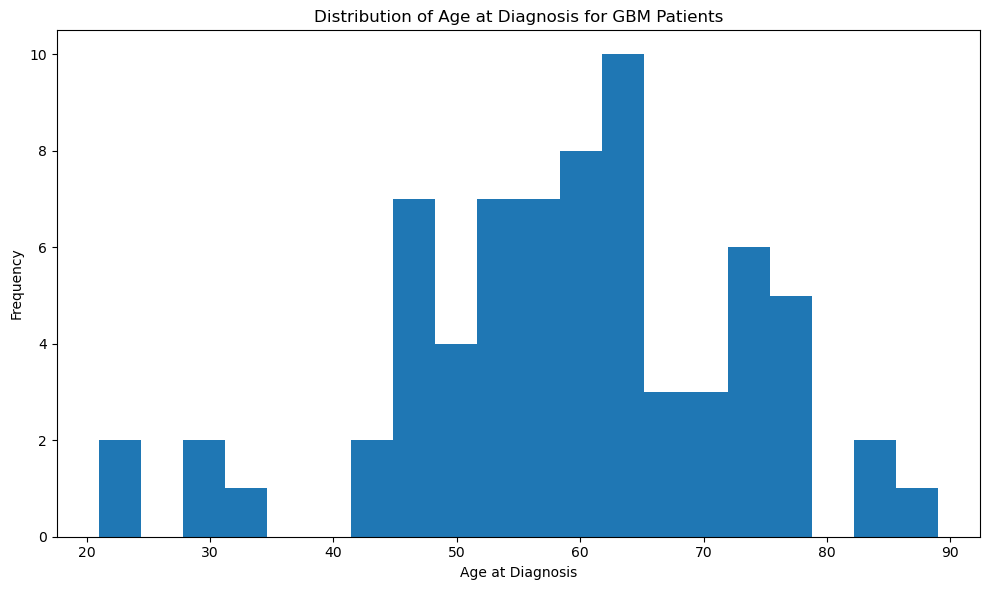

In [59]:
cleaned['age_at_diagnosis'] = pd.to_numeric(cleaned['age_at_diagnosis'], errors='coerce')

plt.figure(figsize=(10, 6))
plt.hist(cleaned['age_at_diagnosis'].dropna(), bins=20)
plt.xlabel('Age at Diagnosis')
plt.ylabel('Frequency')
plt.title('Distribution of Age at Diagnosis for GBM Patients')
plt.tight_layout()
plt.show()


*PCA Dimensionality Reduction and scaling to make it more even between genes*

In [66]:
scaler = StandardScaler()
X = GBM_data.loc[gene_list].values.T
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


*Plot the PCA*

In [67]:
X_pca[:, 0].shape

(80,)

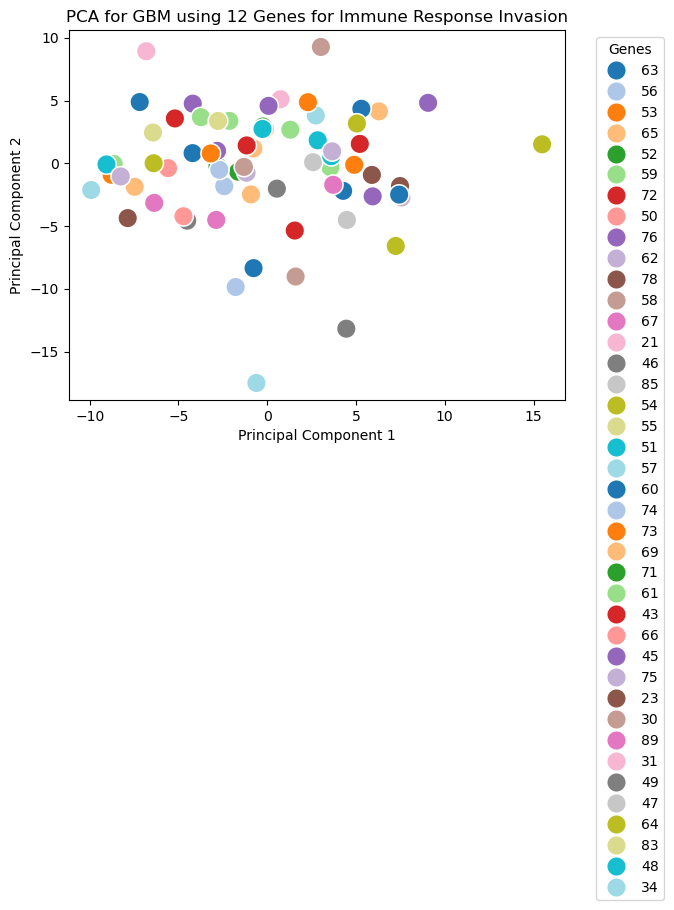

In [68]:
sns.scatterplot(x=X_pca[:, 0], 
                y=X_pca[:, 1], 
                hue= GBM_metadata['age_at_diagnosis'].values, #hue = y used to color the points based on gene labels
                palette="tab20", 
                s=200) # Adjusted this number to make the size of dots bigger

plt.title("PCA for GBM using 12 Genes for Immune Response Invasion")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Genes")
plt.show()

*Vizualize the K-Means Clustering* 

c:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


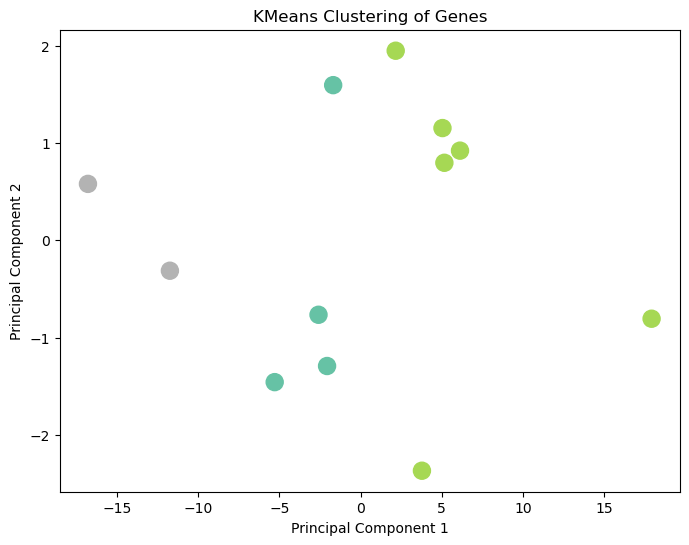

In [ ]:
model = KMeans(n_clusters=3, random_state=0)
model.fit(X_scaled)
y_pred = model.predict(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred, cmap="Set2", s=150)
plt.title("KMeans Clustering of Genes")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

From K-Means and the PCA, we matched the genes in each cluster group:

    Grey group: LCK and PRF1
    Teal group: MAPK14, PTPN6, HCK, and CD86
    Green group: PTK2, HIF1A, Stat3, Stat1, CXCR4, and RHOA

*Hierarchical Clustering using in-class notebook for a guide*

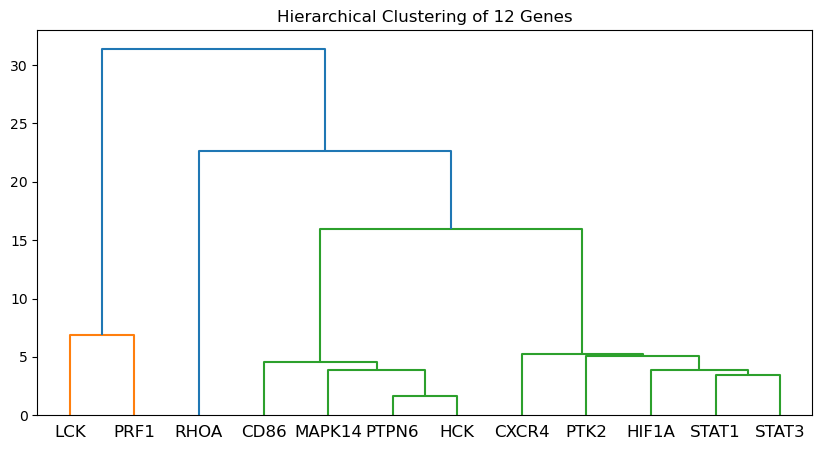

In [ ]:
Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=gene_list) # Label the tree with Gene Names
plt.title("Hierarchical Clustering of 12 Genes")
plt.show()

*DBSCAN Clustering using in class guide once again*

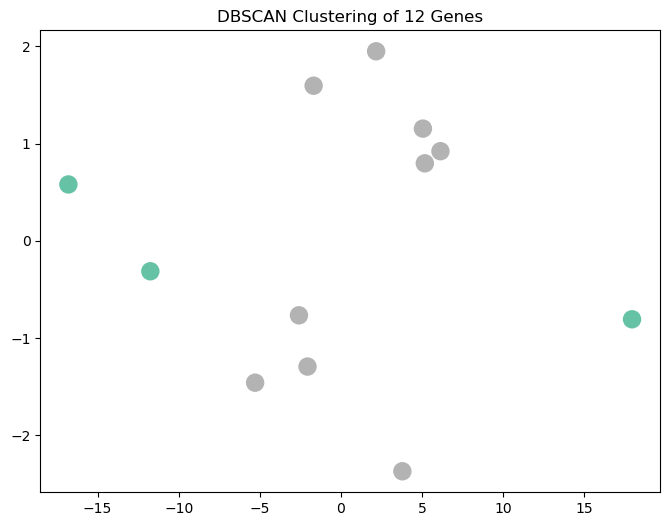

In [ ]:
dbscan = DBSCAN(eps=5.0, min_samples=2) # EPS adjusted for small sample size (12 points)
y_dbscan = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_dbscan, cmap="Set2", s=150)
plt.title("DBSCAN Clustering of 12 Genes")
plt.show()

Teal genes: LCK, PRF1, and RHOA
Grey genes: STAT1, CXCR4, PTPN6, STAT3, CD86, MAPK14, HCK, PTK2, and HIF1A

## Verify and validate your analysis: 
*Pick a SPECIFIC metric to determine how well your model is performing and describe how it works here.*

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*